# Quickstart notebook

The executed companion to the [Quickstart](quickstart.md) page: one Loisel et
al. (2023) scene through the forward model, the two inelastic emission terms
switched on, one gradient, and one figure.

Every output below was produced by running this notebook — the site does not
execute notebooks at build time (`nb_execution_mode = "off"`), so what you are
reading *is* the committed run. It needs **no `$OS_COLOR` and no downloaded
data**: the scene comes from a fixture committed to the repository, which is
what makes the notebook runnable anywhere. It was in fact executed with
`OS_COLOR` unset, and the cell below says so.

For the prose version of the same material — including why the 440 nm gradient
is fluorescence and not Raman — read the [Quickstart](quickstart.md) page.

## 1. The environment

`robust` is not necessarily pip-installed, so walk up to the repository root and
put it on `sys.path`. This is the same pattern the milestone notebooks under
`notebooks/RT/` use, and it keeps the notebook runnable from anywhere in the
checkout.

In [1]:
import os
import sys
from pathlib import Path

REPO = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "robust" / "__init__.py").exists()
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import jax.numpy as jnp

import robust
import robust.rt as rt

print(f"repo    {REPO.name}/")
print(f"robust  {robust.__version__}")
print(f"jax     {jax.__version__}")
print(f"devices {jax.devices()}")
print(f"$OS_COLOR set? {'OS_COLOR' in os.environ}")

repo    retrieve-or-bust/
robust  0.0.dev0
jax     0.11.0
devices [CpuDevice(id=0)]
$OS_COLOR set? False


## 2. One L23 scene

`robust.rt.data.l23` reads the L23 HydroLight archive, but the loader takes a
*reader*, and the repository ships a 50-scene fixture that feeds the real loader
with the real archive's contents. That is what the test suite uses, and it is
why nothing here needs `$OS_COLOR` or the ~17 MB netCDFs.

`forward` takes pytrees, not a batch object, so pulling one sample out gives
exactly the three arguments a caller with their own IOPs would build by hand.

In [2]:
from robust.rt.data import l23

FILES = Path(robust.__file__).parent / "tests" / "files"
batch = l23.load_inelastic_batch(
    reader=l23.inelastic_npz_reader(
        FILES / "l23_inelastic_fixture.npz", FILES / "l23_small.npz"
    )
)

i = 0  # first scene, first solar zenith
iops = rt.IOPs(
    a=batch.iops.a[i],
    bb_w=batch.iops.bb_w[i],
    bb_p=batch.iops.bb_p[i],
    a_ph=batch.iops.a_ph[i],
)
phase_params = rt.PhaseParams(B_p=batch.phase_params.B_p[i])
geometry = rt.Geometry.nadir(batch.geometry.theta_s[i])
wave = batch.wave

iops.validate(wave=wave)
phase_params.validate()
geometry.validate()

print(f"batch     {batch.n_sample} samples x {batch.n_wave} wavelengths, "
      f"{wave[0]:.0f}-{wave[-1]:.0f} nm")
print(f"scene {i}   theta_s = {float(geometry.theta_s):.0f} deg, view nadir")
print(f"a(440)    {float(jnp.interp(440.0, wave, iops.a)):.4f} m^-1  "
      f"(clear water)")
print(f"a_ph(440) {float(jnp.interp(440.0, wave, iops.a_ph)):.4f} m^-1")

batch     150 samples x 81 wavelengths, 350-750 nm
scene 0   theta_s = 0 deg, view nadir
a(440)    0.0167 m^-1  (clear water)
a_ph(440) 0.0037 m^-1


## 3. Elastic, then inelastic

`forward`'s fifth argument is keyword-only. `inelastic=None` — the default — is
the elastic model and is bit-identical to it by construction: the `None` branch
takes the pre-existing code route rather than multiplying by one. Passing an
`Inelastic()` turns on Raman scattering by water and chlorophyll-a fluorescence
together.

In [3]:
Rrs = rt.forward(iops, phase_params, geometry, wave)
Rrs_inel = rt.forward(iops, phase_params, geometry, wave, inelastic=rt.Inelastic())

print(f"Rrs shape {Rrs.shape}, dtype {Rrs.dtype}")
print(f"identical to elastic? {bool(jnp.all(Rrs_inel == Rrs))}")
for lam in (440.0, 550.0, 685.0):
    e = float(jnp.interp(lam, wave, Rrs))
    t = float(jnp.interp(lam, wave, Rrs_inel))
    print(f"  {lam:.0f} nm   {e:.6e} -> {t:.6e} sr^-1   ({100 * (t / e - 1):+.2f} %)")

Rrs shape (81,), dtype float32
identical to elastic? False
  440 nm   8.527968e-03 -> 9.241643e-03 sr^-1   (+8.37 %)
  550 nm   1.207069e-03 -> 1.505374e-03 sr^-1   (+24.71 %)
  685 nm   7.285256e-05 -> 1.225158e-04 sr^-1   (+68.17 %)


## 4. One gradient

This is the point of writing the model in JAX. `forward` is differentiable with
respect to every leaf of every argument, so a derivative with respect to
absorption and a derivative with respect to the fluorescence quantum yield
$\varphi_C$ are the same one-line operation — and the gradient comes back
*labelled*: `grad` of a scalar function of an `IOPs` returns an `IOPs`.

Because the fluorescence term is linear in $\varphi_C$ by construction
($R_{rs}^{fl} = \varphi_C \cdot K_{fl}$), that derivative *is* the fluorescence
kernel. The last two lines check exactly that.

In [4]:
inel = rt.Inelastic()


def Rrs685(iops, inelastic):
    """Rrs at the 685 nm fluorescence peak — a scalar, so ``grad`` applies."""
    out = rt.forward(iops, phase_params, geometry, wave, inelastic=inelastic)
    return jnp.interp(685.0, wave, out)


d_iops = jax.grad(Rrs685, argnums=0)(iops, inel)
d_inel = jax.grad(Rrs685, argnums=1)(iops, inel)

print(f"dRrs(685)/da     shape {d_iops.a.shape}, at 685 nm "
      f"{float(jnp.interp(685.0, wave, d_iops.a)):+.4e}")
print(f"                                at 440 nm "
      f"{float(jnp.interp(440.0, wave, d_iops.a)):+.4e}   (all inelastic)")
print(f"dRrs(685)/da_ph  at 685 nm      "
      f"{float(jnp.interp(685.0, wave, d_iops.a_ph)):+.4e}")
print(f"dRrs(685)/dphi_C                {float(d_inel.phi_C):+.6e} sr^-1")

# phi_C-linearity, in one line: the derivative times phi_C is the whole term.
Rrs_fl = rt.forward(iops, phase_params, geometry, wave,
                    inelastic=rt.Inelastic(raman=False))
at685 = lambda y: float(jnp.interp(685.0, wave, y))
print()
print(f"phi_C * dRrs/dphi_C    = {float(inel.phi_C) * float(d_inel.phi_C):.6e}")
print(f"Rrs_fl(685) - Rrs(685) = {at685(Rrs_fl) - at685(Rrs):.6e}")

dRrs(685)/da     shape (81,), at 685 nm -2.3508e-04
                                at 440 nm -1.1346e-06   (all inelastic)
dRrs(685)/da_ph  at 685 nm      +2.3789e-04
dRrs(685)/dphi_C                +1.482279e-03 sr^-1

phi_C * dRrs/dphi_C    = 2.964558e-05
Rrs_fl(685) - Rrs(685) = 2.964558e-05


## 5. The picture

Raman scattering redistributes blue photons into a broad gain across the red;
fluorescence adds a narrow emission line at 685 nm. Both matter far more than
their absolute magnitude suggests, because both arrive where the elastic signal
has already fallen by three orders of magnitude — which is what the log axis in
the top panel and the percentage axis in the bottom panel are there to show
together.

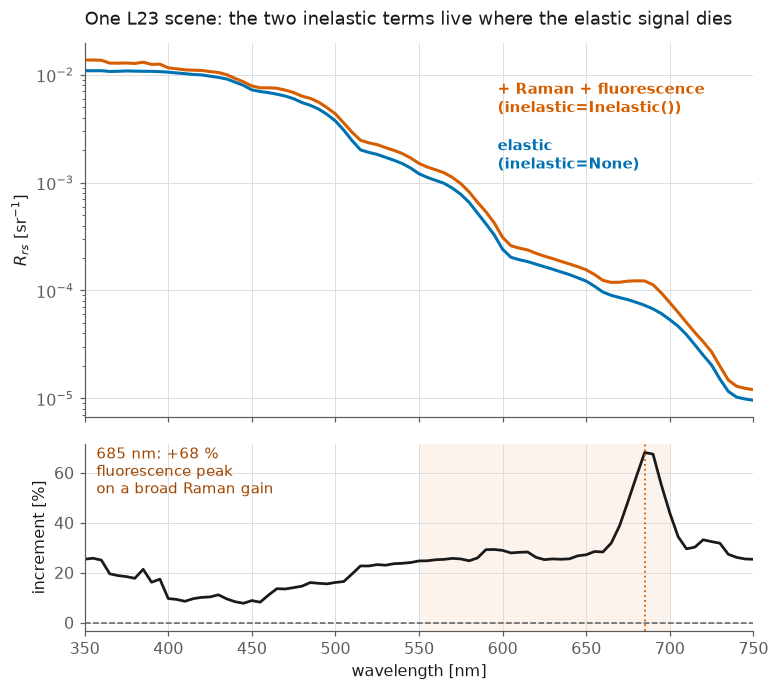

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- house style: recessive frame, ink-coloured text, one figure = one idea ---
INK, INK_MUTED, GRID = "#1a1a1a", "#5c5c5c", "#dcdcdc"
C_A, C_B = "#D55E00", "#0072B2"  # CVD-checked pair (elastic notebook 1)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
    "axes.facecolor": "white",
})

w, e, t = np.asarray(wave), np.asarray(Rrs), np.asarray(Rrs_inel)

fig, (ax, bx) = plt.subplots(2, 1, figsize=(7.2, 6.4), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

ax.plot(w, e, color=C_B, lw=2.0)
ax.plot(w, t, color=C_A, lw=2.0)
ax.set_yscale("log")
# Direct labels in the empty upper right, stacked in the same order as the
# curves themselves, so the figure needs no legend.
ax.text(597, 4.5e-3, "+ Raman + fluorescence\n(inelastic=Inelastic())",
        color=C_A, fontweight="bold", fontsize=10)
ax.text(597, 1.35e-3, "elastic\n(inelastic=None)",
        color=C_B, fontweight="bold", fontsize=10)
ax.set_ylabel(r"$R_{rs}$ [sr$^{-1}$]")
ax.set_title("One L23 scene: the two inelastic terms live where the elastic "
             "signal dies", fontsize=11.5, pad=12, loc="left")

rel = 100.0 * (t - e) / e
peak = float(rel[np.argmin(np.abs(w - 685.0))])
bx.plot(w, rel, color=INK, lw=1.8)
bx.axhline(0.0, color=INK_MUTED, lw=1.0, ls="--")
bx.axvspan(550, 700, color=C_A, alpha=0.07, lw=0)
bx.axvline(685.0, color=C_A, lw=1.2, ls=":")
bx.annotate(f"685 nm: {peak:+.0f} %\nfluorescence peak\non a broad Raman gain",
            xy=(685, peak), xytext=(357, 0.76 * peak),
            color="#a04600", fontsize=9.5)
bx.set_xlim(w.min(), w.max())
bx.set_xlabel("wavelength [nm]")
bx.set_ylabel("increment [%]")
fig.tight_layout()
plt.show()

:::{note}
These are single-scene numbers from a clear-water scene, shown to make the
mechanics concrete. They are **not** the model's accuracy. The measured errors
over the L23 ensemble, and the conditions under which they degrade, live in the
two reports and are summarised on the scope-and-limitations page.
:::

## Where to go next

- [The model in one page](model/overview.md) — the composition law, what each
  term is, and which module owns it.
- [API reference](api.rst) — `forward`'s full signature, the three `mode`
  values, and the four pytrees.
- [Development record](development_record.md) — the ten milestone notebooks the
  model was built in, and the design documents behind them.